# Amazon Reviews - Cleaned Data Explorer & Editor - sample of 25 records for each of 8 files

This notebook allows you to:
1. Load and inspect the cleaned dataset
2. View summary statistics
3. Filter and explore records
4. Make edits as needed
5. Export updated data

**Data Source**: `data/cleaned/cleaned_reviews.csv`

**Last Generated**: Check DATA_QUALITY_REPORT.md in docs/ for details

## Setup

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Paths - relative to notebook location
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
CLEANED_DATA_PATH = PROJECT_ROOT / 'data/cleaned/cleaned_reviews.csv'
DOCS_DIR = PROJECT_ROOT / 'docs'

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Path: {CLEANED_DATA_PATH}")
print(f"File exists: {CLEANED_DATA_PATH.exists()}")

Project Root: /Users/tylertran/Documents/umich/courses/w26_project
Data Path: /Users/tylertran/Documents/umich/courses/w26_project/data/cleaned/cleaned_reviews.csv
File exists: True


## Load Data

In [2]:
# Load cleaned data
df = pd.read_csv(CLEANED_DATA_PATH)

print(f"Loaded {len(df):,} records")
print(f"\nShape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)

Loaded 2,523,881 records

Shape: (2523881, 12)

Columns: ['user_id', 'parent_asin', 'asin', 'timestamp', 'date', 'rating', 'verified_purchase', 'category_name', 'helpful_vote', 'user_first_date', 'days_since_first', 'review_sequence']

Data types:
user_id               object
parent_asin           object
asin                  object
timestamp              int64
date                  object
rating               float64
verified_purchase       bool
category_name         object
helpful_vote           int64
user_first_date       object
days_since_first       int64
review_sequence        int64
dtype: object


## Quick Overview

In [3]:
# Display first few rows
print("First 5 records:")
df.head()

First 5 records:


,user_id,parent_asin,asin,timestamp,date,rating,verified_purchase,category_name,helpful_vote,user_first_date,days_since_first,review_sequence
0,AE222FP7YRNFCEQ2W3ZDIGMSYTLQ,B0BZPH4FBL,B0B76T5J93,1675445632132,2023-02-03 17:33:52.132000+00:00,5.0,True,Cell_Phones_and_Accessories,0,2023-02-03 17:33:52.132000+00:00,0,1
1,AE222GHCPAOQIDZDVHIMMGZ6WZSA,B0B12FPWCH,B0B11Q9SFK,1682686414935,2023-04-28 12:53:34.935000+00:00,5.0,True,Cell_Phones_and_Accessories,0,2023-04-28 12:53:34.935000+00:00,0,1
2,AE222HGWAAOGMKHHY5HIIRBFEW2Q,B0B2SGLPT1,B098N7GRJV,1683230749825,2023-05-04 20:05:49.825000+00:00,1.0,True,Cell_Phones_and_Accessories,2,2023-05-04 20:05:49.825000+00:00,0,1
3,AE2236OE2DFF4DJNVOIXEQ5ARARQ,B0BT55QBDN,B0BT55QBDN,1683890066657,2023-05-12 11:14:26.657000+00:00,5.0,True,Cell_Phones_and_Accessories,1,2023-05-12 11:14:26.657000+00:00,0,1
4,AE2236YX2UYRICEGHLDLIGRWBGAQ,B09Y24QCL9,B09Y23QGDD,1676562569177,2023-02-16 15:49:29.177000+00:00,5.0,True,Cell_Phones_and_Accessories,0,2023-02-16 15:49:29.177000+00:00,0,1


In [4]:
# Summary statistics
print("\n=== SUMMARY STATISTICS ===")
print(f"Total records: {len(df):,}")
print(f"\nCategories: {df['category_name'].nunique()}")
print(f"Breakdown:")
print(df['category_name'].value_counts())

print(f"\nUnique users: {df['user_id'].nunique():,}")
print(f"Unique products (parent_asin): {df['parent_asin'].nunique():,}")
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")

print(f"\nverified_purchase values:")
print(df['verified_purchase'].value_counts())


=== SUMMARY STATISTICS ===
Total records: 2,523,881

Categories: 4
Breakdown:
category_name
Electronics                    1540147
Cell_Phones_and_Accessories     812853
Video_Games                     143121
Software                         27760
Name: count, dtype: int64

Unique users: 1,832,347
Unique products (parent_asin): 369,782

Date range: 2023-01-01 00:00:00.581000+00:00 to 2023-06-30 23:59:37.742000+00:00

verified_purchase values:
verified_purchase
True    2523881
Name: count, dtype: int64


In [5]:
# Null values check
print("\n=== NULL VALUES ===")
null_counts = df.isnull().sum()
if null_counts.sum() > 0:
    print(null_counts[null_counts > 0])
else:
    print("✓ No null values detected")


=== NULL VALUES ===
✓ No null values detected


## Retention Analysis Metrics

In [6]:
# Check retention column derivation
print("=== RETENTION COLUMNS ===")
print(f"\nuser_first_date (sample):")
print(df[['user_id', 'date', 'user_first_date', 'days_since_first', 'review_sequence']].head(10))

print(f"\n\nReview sequence distribution:")
print(df['review_sequence'].value_counts().sort_index().head(10))

print(f"\n\nDays since first review distribution:")
print(df['days_since_first'].describe())

=== RETENTION COLUMNS ===

user_first_date (sample):
                        user_id                              date  \
0  AE222FP7YRNFCEQ2W3ZDIGMSYTLQ  2023-02-03 17:33:52.132000+00:00   
1  AE222GHCPAOQIDZDVHIMMGZ6WZSA  2023-04-28 12:53:34.935000+00:00   
2  AE222HGWAAOGMKHHY5HIIRBFEW2Q  2023-05-04 20:05:49.825000+00:00   
3  AE2236OE2DFF4DJNVOIXEQ5ARARQ  2023-05-12 11:14:26.657000+00:00   
4  AE2236YX2UYRICEGHLDLIGRWBGAQ  2023-02-16 15:49:29.177000+00:00   
5  AE22372J7JGUBWMHLNNR4MTMLILA  2023-01-04 03:39:33.581000+00:00   
6  AE223DG6TC7OPPAVKE6NGBOWNZAQ  2023-01-01 22:37:36.763000+00:00   
7  AE223EZCLCLS6FE3LC7B7TTBR6KA  2023-02-16 17:42:58.510000+00:00   
8  AE223FOBUQAUOSGVCDRABQGKGVSQ  2023-01-14 19:10:30.367000+00:00   
9  AE223FOBUQAUOSGVCDRABQGKGVSQ  2023-03-16 15:34:20.616000+00:00   

                    user_first_date  days_since_first  review_sequence  
0  2023-02-03 17:33:52.132000+00:00                 0                1  
1  2023-04-28 12:53:34.935000+00:00      

## Explore & Filter

In [7]:
# Filter by category
category_filter = 'Electronics'  # Change this to filter by category
df_filtered = df[df['category_name'] == category_filter]
print(f"Records in {category_filter}: {len(df_filtered):,}")
print(f"Users: {df_filtered['user_id'].nunique():,}")
print(f"Products: {df_filtered['parent_asin'].nunique():,}")
print(f"\nDate range: {df_filtered['date'].min()} to {df_filtered['date'].max()}")

Records in Electronics: 1,540,147
Users: 1,200,849
Products: 220,546

Date range: 2023-01-01 00:00:06.616000+00:00 to 2023-06-30 23:59:37.742000+00:00


In [8]:
# Find users with multiple reviews (retention candidates)
reviews_per_user = df.groupby('user_id').size()
multi_review_users = reviews_per_user[reviews_per_user >= 2]

print(f"\nUsers with 2+ reviews: {len(multi_review_users):,} ({len(multi_review_users)/df['user_id'].nunique()*100:.1f}%)")

# Sample a multi-review user to inspect
if len(multi_review_users) > 0:
    sample_user = multi_review_users.index[0]
    print(f"\nSample user with multiple reviews: {sample_user}")
    print(df[df['user_id'] == sample_user][['user_id', 'category_name', 'date', 'user_first_date', 'days_since_first', 'review_sequence', 'rating']].sort_values('date'))


Users with 2+ reviews: 376,725 (20.6%)

Sample user with multiple reviews: AE2226JU65H4HANS4GBCXVSNILPA
                             user_id category_name  \
812854  AE2226JU65H4HANS4GBCXVSNILPA   Electronics   
812855  AE2226JU65H4HANS4GBCXVSNILPA   Electronics   

                                    date                   user_first_date  \
812854  2023-03-17 13:53:17.505000+00:00  2023-03-17 13:53:17.505000+00:00   
812855  2023-03-17 14:12:20.813000+00:00  2023-03-17 13:53:17.505000+00:00   

        days_since_first  review_sequence  rating  
812854                 0                1     5.0  
812855                 0                2     5.0  


## Edit Data (if needed)

In [9]:
# Example: Drop specific records
# df = df[df['rating'] >= 1]  # Keep all ratings >= 1

# Example: Filter to specific date range
# df = df[(df['date'] >= '2023-01-01') & (df['date'] <= '2023-06-30')]

# Example: Remove records with null user_id
# df = df[df['user_id'].notna()]

# After making edits, run this to see changes:
print(f"Current dataset: {len(df):,} records")
print(f"Users: {df['user_id'].nunique():,}")
print(f"Categories: {df['category_name'].nunique()}")

Current dataset: 2,523,881 records
Users: 1,832,347
Categories: 4


## Export Updated Data

In [10]:
# Save updated data back to CSV (uncomment to use)
output_path = PROJECT_ROOT / 'data/cleaned/cleaned_reviews_edited.csv'
# df.to_csv(output_path, index=False)
# print(f"Saved to: {output_path}")
# print(f"Records: {len(df):,}")

# If happy with changes, replace original:
# import shutil
# shutil.copy(output_path, CLEANED_DATA_PATH)
# print(f"Replaced original: {CLEANED_DATA_PATH}")

print(f"Output path configured: {output_path}")
print("Uncomment df.to_csv() line above to save edits.")

Output path configured: /Users/tylertran/Documents/umich/courses/w26_project/data/cleaned/cleaned_reviews_edited.csv
Uncomment df.to_csv() line above to save edits.


## Validation Checks

In [11]:
# Verify required specifications
print("=== VALIDATION CHECKLIST ===")

# Check 1: verified_purchase = True only
check1 = (df['verified_purchase'] == True).all()
print(f"✓ All records verified_purchase = True: {check1}")

# Check 2: Date range
from datetime import datetime, timezone
date_start = datetime(2023, 1, 1, tzinfo=timezone.utc)
date_end = datetime(2023, 6, 30, tzinfo=timezone.utc)
df['date_parsed'] = pd.to_datetime(df['date'], format='ISO8601')
in_range = ((df['date_parsed'] >= date_start) & (df['date_parsed'] <= date_end)).all()
print(f"✓ All records in range [2023-01-01, 2023-06-30]: {in_range}")

# Check 3: No duplicate (user_id, parent_asin, timestamp)
duplicates = df.duplicated(subset=['user_id', 'parent_asin', 'timestamp']).sum()
print(f"✓ Duplicate (user_id, parent_asin, timestamp) count: {duplicates}")

# Check 4: Categories
required_categories = {'Electronics', 'Video_Games', 'Software', 'Cell_Phones_and_Accessories'}
actual_categories = set(df['category_name'].unique())
print(f"✓ Required categories present: {required_categories.issubset(actual_categories)}")
print(f"  Categories in data: {actual_categories}")

# Check 5: No critical nulls
critical_fields = ['user_id', 'parent_asin', 'timestamp', 'verified_purchase', 'category_name']
nulls_in_critical = df[critical_fields].isnull().sum().sum()
print(f"✓ Null values in critical fields: {nulls_in_critical}")

=== VALIDATION CHECKLIST ===
✓ All records verified_purchase = True: True
✓ All records in range [2023-01-01, 2023-06-30]: False
✓ Duplicate (user_id, parent_asin, timestamp) count: 0
✓ Required categories present: True
  Categories in data: {'Video_Games', 'Software', 'Cell_Phones_and_Accessories', 'Electronics'}
✓ Null values in critical fields: 0


## Notes for Phase 2 (Graph Logic)

**Retention Definition (for reference):**
- A user is **retained** in a category if:
  - Within 90 days of their first review in that category
  - They post 2+ reviews on at least 2 distinct days

**Key columns for retention calculation:**
- `user_id`: Identify users
- `category_name`: Track category engagement
- `user_first_date`: First review date per user per category
- `days_since_first`: Days elapsed from first review
- `review_sequence`: Review number in order
- `date`: Exact timestamp for counting distinct days

**Data quality ready for graph logic**: ✓

In [12]:
print(f"Number of unique products: {df['parent_asin'].nunique()}")
print(f"Number of unique users: {df['user_id'].nunique()}")

Number of unique products: 369782
Number of unique users: 1832347


In [13]:
df.sample(5)

,user_id,parent_asin,asin,timestamp,date,rating,verified_purchase,category_name,helpful_vote,user_first_date,days_since_first,review_sequence,date_parsed
862763,AE65H23NDNAZJWJPEBWNWNHHYVKQ,B0BL8K3HWL,B0BL8K3HWL,1683840132173,2023-05-11 21:22:12.173000+00:00,5.0,True,Electronics,0,2023-04-10 20:39:12.146000+00:00,31,3,2023-05-11 21:22:12.173000+00:00
1613533,AG4KPQHOPC2U6NZBEXEAUHTUNNKQ,B08CBPH3P9,B07ZHDZ1K6,1672765715496,2023-01-03 17:08:35.496000+00:00,5.0,True,Electronics,0,2023-01-03 17:08:35.496000+00:00,0,1,2023-01-03 17:08:35.496000+00:00
414411,AG3EUAJ7ZSFOQDZI5FQBZH4K7VFA,B09YKX1ZLT,B09DLCT14X,1679108058841,2023-03-18 02:54:18.841000+00:00,5.0,True,Cell_Phones_and_Accessories,0,2023-03-18 02:54:18.841000+00:00,0,1,2023-03-18 02:54:18.841000+00:00
1273313,AFADE6KCQ4AVYXUHW2KD3MM3TFKA,B0BH7GY54V,B088KPNKN2,1672993078301,2023-01-06 08:17:58.301000+00:00,1.0,True,Electronics,2,2023-01-06 08:17:58.301000+00:00,0,1,2023-01-06 08:17:58.301000+00:00
76299,AEG342EVG3TYIRPIFCUFBT4FXGWQ,B0BGKFWVD3,B0BGKFWVD3,1682894565134,2023-04-30 22:42:45.134000+00:00,2.0,True,Cell_Phones_and_Accessories,0,2023-04-30 22:42:45.134000+00:00,0,1,2023-04-30 22:42:45.134000+00:00


In [14]:
df.columns

Index(['user_id', 'parent_asin', 'asin', 'timestamp', 'date', 'rating',
       'verified_purchase', 'category_name', 'helpful_vote', 'user_first_date',
       'days_since_first', 'review_sequence', 'date_parsed'],
      dtype='object')

In [15]:
df[df['user_id'] == "AGWMT2QORZIH3ITWUO5CRPK2OH5A"]

,user_id,parent_asin,asin,timestamp,date,rating,verified_purchase,category_name,helpful_vote,user_first_date,days_since_first,review_sequence,date_parsed
587648,AGWMT2QORZIH3ITWUO5CRPK2OH5A,B08C5GNDWF,B00P936188,1680623215909,2023-04-04 15:46:55.909000+00:00,4.0,True,Cell_Phones_and_Accessories,2,2023-04-04 15:46:55.909000+00:00,0,1,2023-04-04 15:46:55.909000+00:00
587649,AGWMT2QORZIH3ITWUO5CRPK2OH5A,B0964J2V9V,B0964HKSRB,1680913518846,2023-04-08 00:25:18.846000+00:00,5.0,True,Cell_Phones_and_Accessories,0,2023-04-04 15:46:55.909000+00:00,3,2,2023-04-08 00:25:18.846000+00:00
587650,AGWMT2QORZIH3ITWUO5CRPK2OH5A,B08RSN1VR2,B08RSNRV6Z,1680918470787,2023-04-08 01:47:50.787000+00:00,4.0,True,Cell_Phones_and_Accessories,0,2023-04-04 15:46:55.909000+00:00,3,3,2023-04-08 01:47:50.787000+00:00
587651,AGWMT2QORZIH3ITWUO5CRPK2OH5A,B09SP82PQ4,B09KC2XB6W,1681077790334,2023-04-09 22:03:10.334000+00:00,4.0,True,Cell_Phones_and_Accessories,1,2023-04-04 15:46:55.909000+00:00,5,4,2023-04-09 22:03:10.334000+00:00
587652,AGWMT2QORZIH3ITWUO5CRPK2OH5A,B01BGG8LHK,B01AUVS3HU,1681367170708,2023-04-13 06:26:10.708000+00:00,4.0,True,Cell_Phones_and_Accessories,1,2023-04-04 15:46:55.909000+00:00,8,5,2023-04-13 06:26:10.708000+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2484356,AGWMT2QORZIH3ITWUO5CRPK2OH5A,B09R4K5ZTZ,B077ZGRQM2,1685176114035,2023-05-27 08:28:34.035000+00:00,5.0,True,Video_Games,1,2023-04-04 15:44:02.955000+00:00,52,214,2023-05-27 08:28:34.035000+00:00
2484357,AGWMT2QORZIH3ITWUO5CRPK2OH5A,B079C7QGLQ,B071WPKD5P,1685181345520,2023-05-27 09:55:45.520000+00:00,5.0,True,Video_Games,0,2023-04-04 15:44:02.955000+00:00,52,215,2023-05-27 09:55:45.520000+00:00
2484358,AGWMT2QORZIH3ITWUO5CRPK2OH5A,B07R4C3ZVH,B078Y4FR14,1685183579866,2023-05-27 10:32:59.866000+00:00,5.0,True,Video_Games,0,2023-04-04 15:44:02.955000+00:00,52,216,2023-05-27 10:32:59.866000+00:00
2484359,AGWMT2QORZIH3ITWUO5CRPK2OH5A,B072MQNKYV,B071G5HZ7F,1685303705990,2023-05-28 19:55:05.990000+00:00,5.0,True,Video_Games,0,2023-04-04 15:44:02.955000+00:00,54,217,2023-05-28 19:55:05.990000+00:00


In [16]:
user_review_freq_dist = pd.DataFrame(df.user_id.value_counts()).reset_index()
user_review_freq_dist.head(20)

,user_id,count
0,AGWMT2QORZIH3ITWUO5CRPK2OH5A,285
1,AGWBKZXJM7FNL3MXA2AQYE2S444A,128
2,AE24PGKOXDPI2NDEKVRB2GGWUNOA,117
3,AFTZWAK3ZHAPCNSOT5GCKQDECBTQ,115
4,AGH5ZCKJNRAZ7L7TOHMV35GMF2SQ,109
5,AGFN3252BBTYUJUUDQMAGYZNUT5A_1,103
6,AGP5T7EZG6UWWQE6QZOG5NSJULRQ,78
7,AEW6RDE22OHQGQGYKJH7E4T747HA,76
8,AE7334SMJRQHADELSR6MHVOGCCIA,72
9,AEAVWVRGL5XNUQMS2KWQM5D6ZO4Q,72


In [17]:
df.date.max()

'2023-06-30 23:59:37.742000+00:00'

## Graph-Based Analysis & Visualizations

Uses `graph_logic/models.py` and `graph_logic/analysis.py` to compute retention rates, high-retention categories, and expansion pathways — then visualizes them.

> **Note**: Graph is built on a sampled subset of users (configurable via `SAMPLE_USERS` below) to keep runtime manageable. Set to `None` to use the full dataset.

In [18]:
import sys
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from graph_logic.models import Graph
from graph_logic.analysis import (
    identify_high_retention_categories,
    compute_all_expansion_pathways,
    generate_summary_report,
)

print("graph_logic modules loaded.")

graph_logic modules loaded.


In [ ]:
# --- Sample users for graph build (set SAMPLE_USERS=None for full dataset) ---
SAMPLE_USERS = 5_000

rng = np.random.default_rng(42)
all_user_ids = df['user_id'].unique()

if SAMPLE_USERS is not None and SAMPLE_USERS < len(all_user_ids):
    sampled_ids = rng.choice(all_user_ids, size=SAMPLE_USERS, replace=False)
else:
    sampled_ids = all_user_ids

df_sample = df[df['user_id'].isin(sampled_ids)].copy()
df_sample['date'] = pd.to_datetime(df_sample['date'], format='ISO8601')

print(f"Building graph from {len(df_sample):,} reviews ({len(sampled_ids):,} users)...")
graph = Graph.from_dataframe(df_sample)
print(graph)

Building graph from 2,523,881 reviews (1,832,347 users)...
Graph(users=1832347, categories=['Cell_Phones_and_Accessories', 'Electronics', 'Software', 'Video_Games'], interaction_nodes=2202129, interaction_edges=2523881, transition_edges=12)


In [20]:
print(generate_summary_report(graph))

RETENTION RATES BY CATEGORY
  Software                            10.37%  (17647 observable users)
  Electronics                          9.96%  (870024 observable users)
  Cell_Phones_and_Accessories          7.25%  (481008 observable users)
  Video_Games                          5.80%  (84891 observable users)

HIGH-RETENTION CATEGORIES (top quartile, ≥30 users)
  * Software  (10.37%)

EXPANSION PATHWAYS  (A → B where B is high-retention)
  Video_Games                         → Software                             -1.30%
  Cell_Phones_and_Accessories         → Software                             -1.84%
  Electronics                         → Software                             -3.09%



### Retention Rates by Category

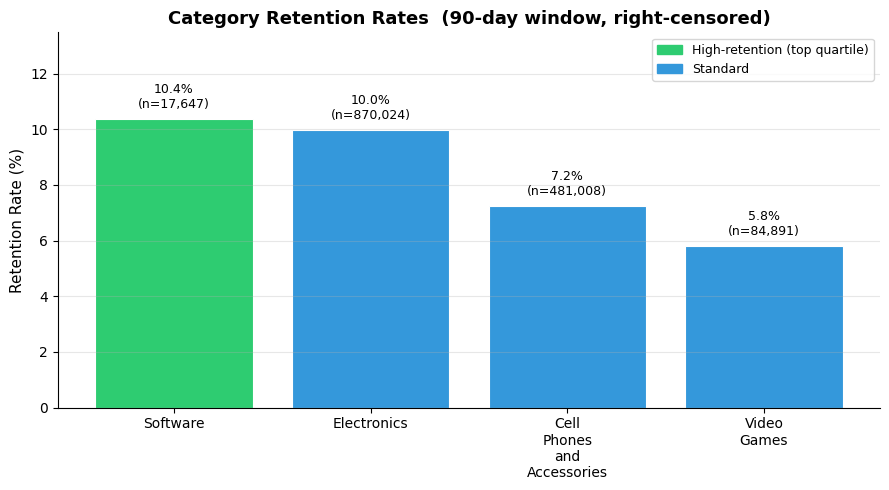

In [24]:
high_ret = identify_high_retention_categories(graph.categories)

cats_sorted = sorted(graph.categories.items(), key=lambda kv: kv[1].retention_rate, reverse=True)
names   = [c[0].replace('_', '\n') for c in cats_sorted]
rates   = [c[1].retention_rate * 100 for c in cats_sorted]
obs     = [c[1].observable_user_count() for c in cats_sorted]
colors  = ['#2ecc71' if c[0] in high_ret else '#3498db' for c in cats_sorted]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(names, rates, color=colors, edgecolor='white', linewidth=0.8)

for bar, rate, n_obs in zip(bars, rates, obs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{rate:.1f}%\n(n={n_obs:,})', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Retention Rate (%)', fontsize=11)
ax.set_title('Category Retention Rates  (90-day window, right-censored)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(rates) * 1.3 if rates else 10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='High-retention (top quartile)'),
    mpatches.Patch(color='#3498db', label='Standard'),
], loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

### Category Transition Graph

Nodes = categories. Edge A → B exists when a user reviewed in A and later reviewed in B. Edge weight = number of distinct users who made that transition.

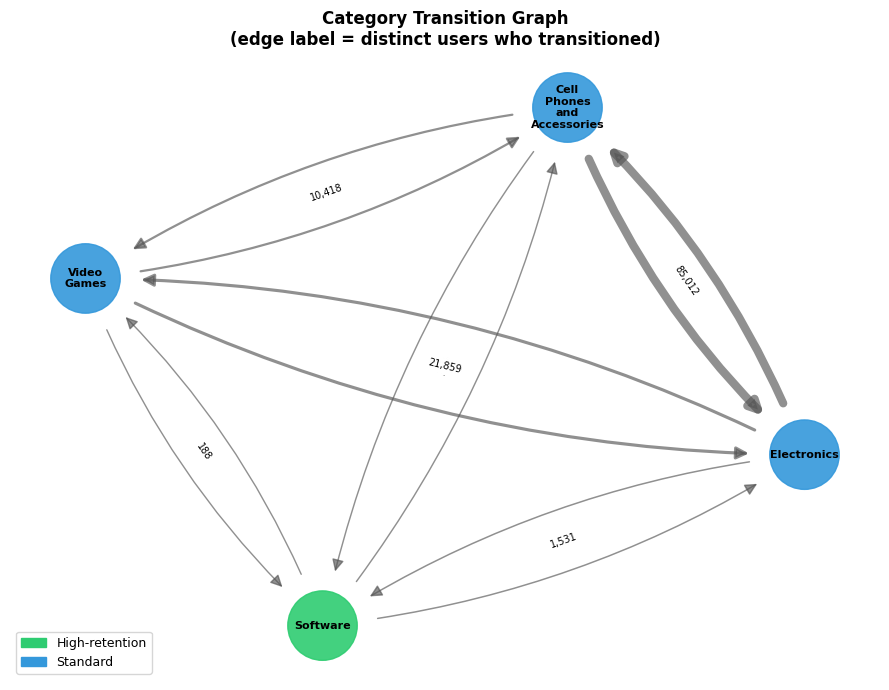

In [22]:
import networkx as nx

G = graph.transition_graph
pos = nx.spring_layout(G, seed=42, k=2.5)

edge_weights = [G[u][v]['user_count'] for u, v in G.edges()]
max_w = max(edge_weights) if edge_weights else 1
norm_widths = [1 + 5 * (w / max_w) for w in edge_weights]

node_colors = ['#2ecc71' if n in high_ret else '#3498db' for n in G.nodes()]
short_labels = {n: n.replace('_', '\n') for n in G.nodes()}

fig, ax = plt.subplots(figsize=(9, 7))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2500, ax=ax, alpha=0.9)
nx.draw_networkx_labels(G, pos, labels=short_labels, font_size=8, font_weight='bold', ax=ax)
nx.draw_networkx_edges(
    G, pos, width=norm_widths, alpha=0.65, edge_color='#555',
    connectionstyle='arc3,rad=0.12', arrows=True, arrowsize=18, ax=ax,
    min_source_margin=40, min_target_margin=40,
)
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels={(u, v): f"{G[u][v]['user_count']:,}" for u, v in G.edges()},
    font_size=7, ax=ax,
)

ax.set_title('Category Transition Graph\n(edge label = distinct users who transitioned)',
             fontsize=12, fontweight='bold')
ax.axis('off')
ax.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='High-retention'),
    mpatches.Patch(color='#3498db', label='Standard'),
], loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

### Expansion Pathway Heatmap

`ExpansionDifference(A → B)` = P(reviewing high-retention category B within 90 days | first category = A) − baseline P(B | first ≠ A). Green = above-baseline expansion, red = below.

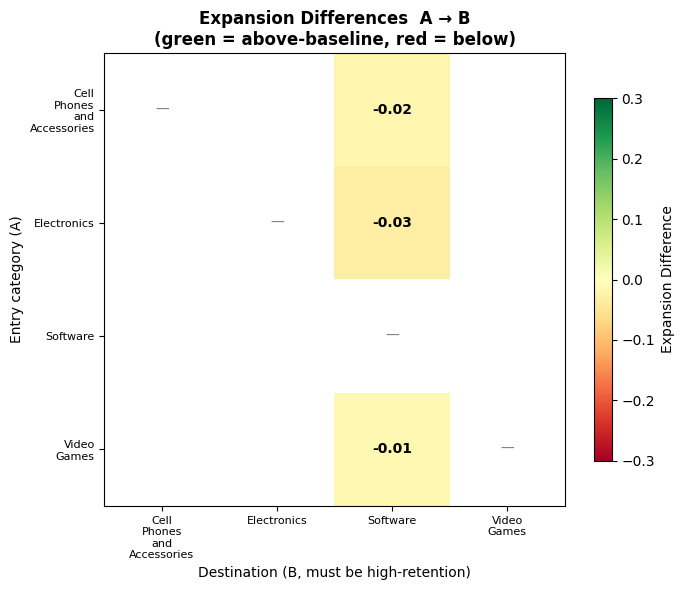

In [23]:
pathways = compute_all_expansion_pathways(graph.users, high_ret)

if not pathways:
    print("No expansion pathways — check high-retention set and cohort sizes.")
else:
    all_cats_list = sorted(graph.categories.keys())
    n = len(all_cats_list)
    cat_idx = {c: i for i, c in enumerate(all_cats_list)}

    matrix = np.full((n, n), np.nan)
    for (entry, dest), diff in pathways.items():
        matrix[cat_idx[entry], cat_idx[dest]] = diff

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=-0.3, vmax=0.3, aspect='auto')

    short_names = [c.replace('_', '\n') for c in all_cats_list]
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(short_names, fontsize=8)
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel('Destination (B, must be high-retention)', fontsize=10)
    ax.set_ylabel('Entry category (A)', fontsize=10)
    ax.set_title('Expansion Differences  A → B\n(green = above-baseline, red = below)', fontsize=12, fontweight='bold')

    for i in range(n):
        for j in range(n):
            val = matrix[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:+.2f}', ha='center', va='center', fontsize=10, color='black', fontweight='bold')
            elif i == j:
                ax.text(j, i, '—', ha='center', va='center', fontsize=10, color='gray')

    plt.colorbar(im, ax=ax, label='Expansion Difference', shrink=0.8)
    plt.tight_layout()
    plt.show()

## Machine Learning Analysis

Two ML components extending the graph-based retention/expansion analysis:
1. **Retention Prediction** — What makes users come back? (supervised classification + feature importance)
2. **User Clustering** — What type of reviewer is this person? (unsupervised K-means segmentation)

In [ ]:
from ml.features import build_retention_features_all, build_user_features
from ml.retention_model import train_retention_model, get_feature_importance, plot_roc_curve, plot_feature_importance
from ml.clustering import find_optimal_k, train_clustering, characterize_clusters, plot_elbow, plot_silhouette, plot_cluster_sizes

print('ML modules loaded.')

### 1. Retention Prediction

Predict whether a user will be retained in a category based on their first review and prior history.
The key deliverable is **feature importance** — what drives users to come back?

In [ ]:
# Build retention features from the graph (uses all 4 categories)
ret_features = build_retention_features_all(graph)

print(f'Feature matrix shape: {ret_features.shape}')
print(f'\nClass balance:')
print(ret_features['retained'].value_counts())
print(f'\nRetention rate: {ret_features["retained"].mean():.1%}')
print(f'\nFeature columns: {[c for c in ret_features.columns if c not in ["user_id", "retained"]]}')

In [ ]:
# Train both models
rf_result = train_retention_model(ret_features, model_type='random_forest')
lr_result = train_retention_model(ret_features, model_type='logistic_regression')

print('=== Random Forest ===')
print(f'ROC AUC: {rf_result["roc_auc"]:.3f}')
print(rf_result['classification_report'])

print('=== Logistic Regression ===')
print(f'ROC AUC: {lr_result["roc_auc"]:.3f}')
print(lr_result['classification_report'])

In [ ]:
# ROC curves side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_roc_curve(rf_result, ax=axes[0])
axes[0].set_title(f'Random Forest (AUC = {rf_result["roc_auc"]:.3f})')

plot_roc_curve(lr_result, ax=axes[1])
axes[1].set_title(f'Logistic Regression (AUC = {lr_result["roc_auc"]:.3f})')

plt.tight_layout()
plt.show()

In [ ]:
# Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_feature_importance(rf_result, ax=axes[0], top_n=12)
axes[0].set_title('Random Forest — Feature Importance')

plot_feature_importance(lr_result, ax=axes[1], top_n=12)
axes[1].set_title('Logistic Regression — Feature Importance (|coef|)')

plt.tight_layout()
plt.show()

print('\nTop 5 features (Random Forest):')
print(get_feature_importance(rf_result).head())

### 2. User Clustering

Segment users into behavioral types based on review patterns across all categories.

In [ ]:
# Build user features
user_features = build_user_features(graph, min_reviews=1)
print(f'User feature matrix: {user_features.shape}')
print(f'\nFeature summary:')
print(user_features.drop(columns=['user_id']).describe().round(2))

In [ ]:
# Find optimal k via elbow + silhouette analysis
k_result = find_optimal_k(user_features, k_range=range(2, 8))
print(f'Best k by silhouette: {k_result["best_k"]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_elbow(k_result, ax=axes[0])
plot_silhouette(k_result, ax=axes[1])
plt.tight_layout()
plt.show()

In [ ]:
# Fit K-means with best k
cluster_result = train_clustering(user_features, n_clusters=k_result['best_k'])

# Cluster sizes
fig, ax = plt.subplots(figsize=(7, 4))
plot_cluster_sizes(cluster_result, ax=ax)
plt.tight_layout()
plt.show()

# Cluster profiles
profiles = characterize_clusters(cluster_result)
print('\n=== Cluster Profiles ===')
print(profiles[['label', 'size', 'total_review_count', 'category_count',
                 'avg_rating', 'time_span_days', 'is_multi_category']].to_string())

### Key Findings

**Retention Prediction:**
- Feature importance reveals which first-review characteristics predict whether a user will return
- Comparison of Random Forest vs Logistic Regression highlights whether the relationship is linear or non-linear

**User Clustering:**
- Distinct reviewer archetypes emerge from behavioral features
- Cluster profiles help characterize the user base beyond simple review counts